<a href="https://colab.research.google.com/github/swastiverma07-gif/project1/blob/main/CreditCard_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# PROJECT: Cybersecurity Risks & Mitigation Strategies in FinTech / Digital Banking
# TASK: End-to-End Credit Card Fraud Detection Pipeline
# ENVIRONMENT: Google Colab

In [11]:
import os
import io
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, auc,
                             f1_score, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from google.colab import files

print("✅ Libraries successfully imported.")


✅ Libraries successfully imported.


In [5]:
import os
import urllib.request
import zipfile

# Direct mirror link for the ULB creditcard.csv dataset
url = "https://media.githubusercontent.com/media/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

print("Downloading dataset...")
# Download direct file or run via kaggle API
!wget -O creditcard.csv https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

print("✅ File 'creditcard.csv' ready in Colab environment!")

--2026-07-08 03:07:19--  https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.101.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 150828752 (144M) [text/csv]
Saving to: ‘creditcard.csv’

creditcard.csv      100%[===================>] 143.84M   147MB/s    in 1.0s    

2026-07-08 03:07:21 (147 MB/s) - ‘creditcard.csv’ saved [150828752/150828752]

✅ File 'creditcard.csv' ready in Colab environment!


In [6]:
def load_data():
    """
    Robust data loader for Google Colab:
    1. Checks if 'creditcard.csv' exists in the local Colab directory.
    2. Prompts manual upload if not found locally.
    3. Falls back to synthetic data if no file is provided.
    """
    print("\n--- DATA LOADING PHASE ---")

    filename = 'creditcard.csv'

    # Check 1: Did we already download 'creditcard.csv' via wget or prior upload?
    if os.path.exists(filename):
        print(f"✅ Found '{filename}' in local Colab directory. Loading...")
        return pd.read_csv(filename)

    # Check 2: Try interactive file upload
    print("No local 'creditcard.csv' found. Please upload your dataset below.")
    try:
        uploaded = files.upload()
        if uploaded and len(uploaded) > 0:
            file_name = list(uploaded.keys())[0]
            df = pd.read_csv(io.BytesIO(uploaded[file_name]))
            print(f"\n✅ Custom dataset successfully loaded: {file_name}")
            return df
        else:
            print("\n⚠️ File upload prompt was cancelled or empty.")
    except Exception as e:
        print(f"\n⚠️ Upload error encountered: {e}")

    # Check 3: Automatic Synthetic Data Fallback
    print("Generating synthetic FinTech dataset for testing...")
    np.random.seed(42)
    n_samples = 50000

    v_features = np.random.randn(n_samples, 28)
    time = np.random.uniform(0, 172800, size=(n_samples, 1))
    amount = np.random.exponential(scale=100, size=(n_samples, 1))
    class_target = np.random.choice([0, 1], size=(n_samples, 1), p=[0.998, 0.002])

    v_features[class_target.ravel() == 1, :5] += np.random.uniform(2, 5, size=(class_target.ravel() == 1).sum())

    data = np.hstack([time, v_features, amount, class_target])
    cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
    df = pd.DataFrame(data, columns=cols)
    df['Class'] = df['Class'].astype(int)

    print("✅ Synthetic dataset created successfully.")
    return df

df = load_data()


--- DATA LOADING PHASE ---
✅ Found 'creditcard.csv' in local Colab directory. Loading...


In [7]:
print("\n--- DATA EXPLORATION ---")
print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")

# Class Imbalance Analysis
fraud_count = df['Class'].value_counts()
fraud_percentage = (df['Class'].value_counts(normalize=True) * 100).to_dict()

print("\nTarget Distribution:")
print(f"Genuine Transactions (0): {fraud_count.get(0, 0)} ({fraud_percentage.get(0, 0):.3f}%)")
print(f"Fraudulent Transactions (1): {fraud_count.get(1, 0)} ({fraud_percentage.get(1, 0):.3f}%)")

# Preprocessing: Scale 'Amount' and 'Time' (V1-V28 are usually already scaled via PCA)
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop raw 'Time' and 'Amount'
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Train-Test Split (Stratified to maintain class ratio in split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} | Test set size: {X_test.shape[0]}")


--- DATA EXPLORATION ---
Dataset Shape: (284807, 31)
Missing Values: 0

Target Distribution:
Genuine Transactions (0): 284315 (99.827%)
Fraudulent Transactions (1): 492 (0.173%)

Training set size: 227845 | Test set size: 56962


In [8]:
print("\n--- APPLYING MITIGATION STRATEGY: SMOTE OVERSAMPLING ---")
smote = SMOTE(sampling_strategy=0.2, random_state=42) # Resample minority to 20% of majority
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original Training Class Distribution: {dict(y_train.value_counts())}")
print(f"Resampled Training Class Distribution: {dict(y_train_res.value_counts())}")


--- APPLYING MITIGATION STRATEGY: SMOTE OVERSAMPLING ---
Original Training Class Distribution: {0: np.int64(227451), 1: np.int64(394)}
Resampled Training Class Distribution: {0: np.int64(227451), 1: np.int64(45490)}


In [9]:
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost Classifier": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

print("\n--- MODEL TRAINING AND EVALUATION ---")
for name, model in models.items():
    print(f"\nTraining: {name}...")
    model.fit(X_train_res, y_train_res)

    # Predict probabilities (essential for financial fraud thresholds)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    # Calculate key FinTech security metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_vals, precision_vals)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "model_object": model,
        "y_pred_proba": y_pred_proba,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "F1_Score": f1,
        "Confusion_Matrix": confusion_matrix(y_test, y_pred)
    }
    print(f"-> ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1-Score: {f1:.4f}")


--- MODEL TRAINING AND EVALUATION ---

Training: Logistic Regression (Baseline)...
-> ROC-AUC: 0.9670 | PR-AUC: 0.7484 | F1-Score: 0.3366

Training: Random Forest Classifier...
-> ROC-AUC: 0.9679 | PR-AUC: 0.8704 | F1-Score: 0.8586

Training: XGBoost Classifier...
-> ROC-AUC: 0.9763 | PR-AUC: 0.8677 | F1-Score: 0.8384


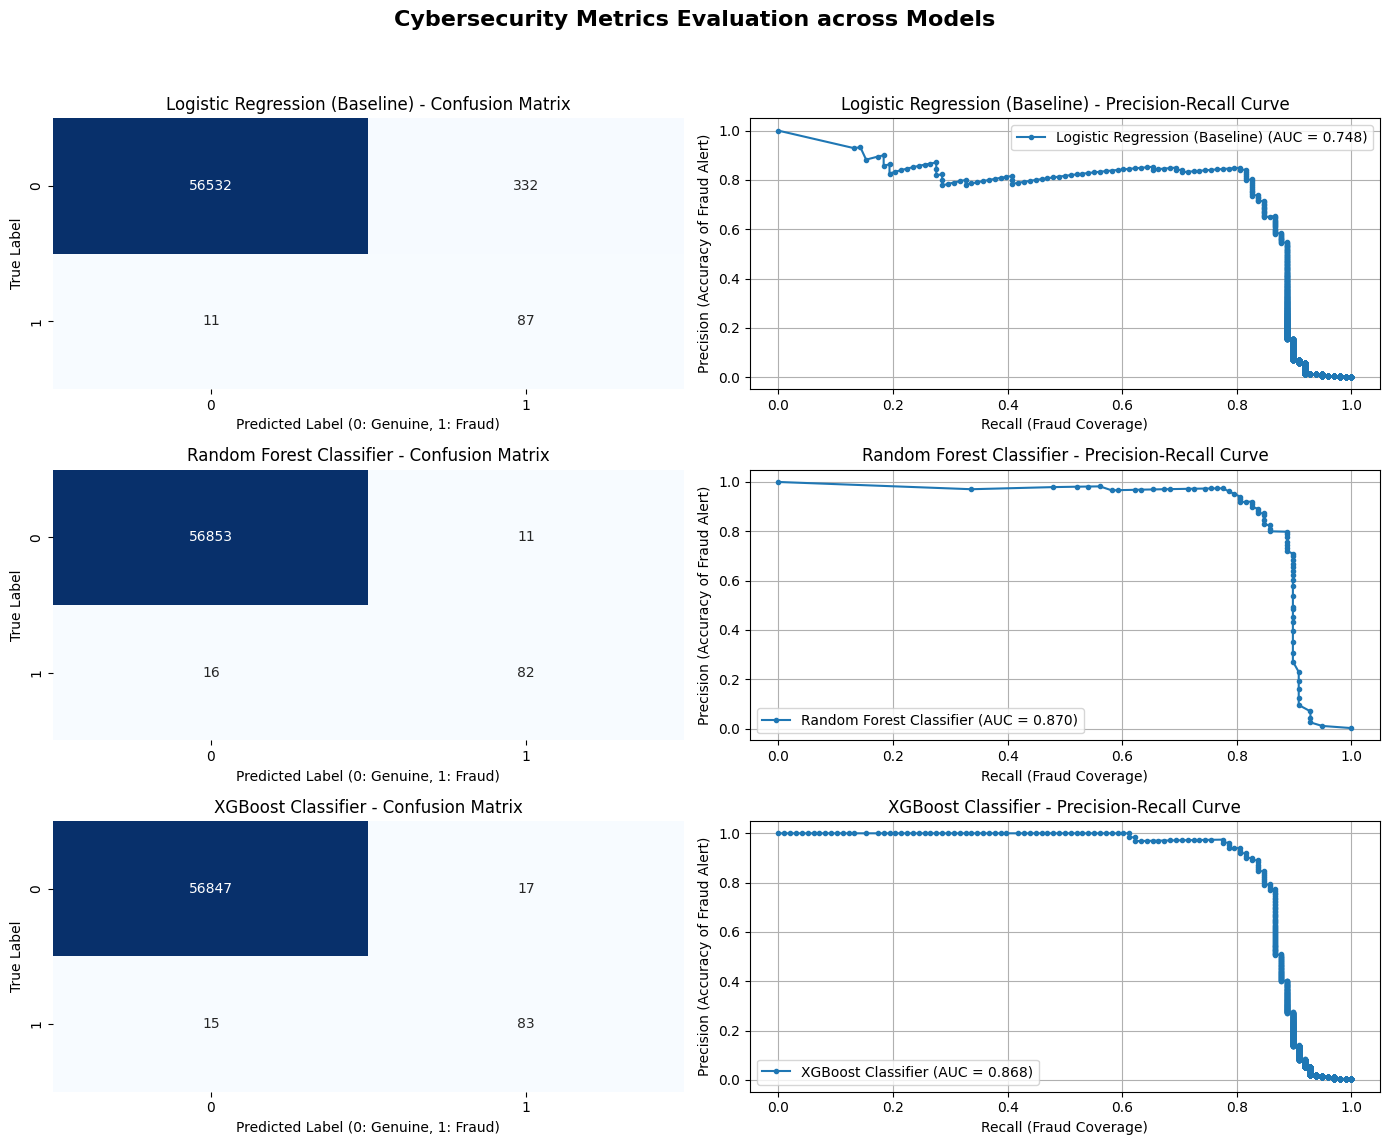

In [12]:
fig, axes = plt.subplots(len(models), 2, figsize=(14, 12))
fig.suptitle("Cybersecurity Metrics Evaluation across Models", fontsize=16, fontweight='bold')

for i, (name, res) in enumerate(results.items()):
    # Plot 1: Confusion Matrix
    cm = res["Confusion_Matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i, 0], cbar=False)
    axes[i, 0].set_title(f"{name} - Confusion Matrix")
    axes[i, 0].set_xlabel("Predicted Label (0: Genuine, 1: Fraud)")
    axes[i, 0].set_ylabel("True Label")

    # Plot 2: Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, res["y_pred_proba"])
    axes[i, 1].plot(recall, precision, marker='.', label=f'{name} (AUC = {res["PR_AUC"]:.3f})')
    axes[i, 1].set_title(f"{name} - Precision-Recall Curve")
    axes[i, 1].set_xlabel("Recall (Fraud Coverage)")
    axes[i, 1].set_ylabel("Precision (Accuracy of Fraud Alert)")
    axes[i, 1].grid(True)
    axes[i, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [13]:
print("\n--- THRESHOLD OPTIMIZATION (RISK APPETITE TUNING) ---")
best_model_name = max(results, key=lambda k: results[k]['PR_AUC'])
best_proba = results[best_model_name]["y_pred_proba"]
print(f"Optimal Model Selected: {best_model_name}")

thresholds = np.arange(0.1, 0.9, 0.1)
print(f"\nEvaluating Threshold Tuning for {best_model_name}:")
print(f"{'Threshold':<12}{'Precision':<12}{'Recall (Detection Rate)':<25}{'F1-Score':<12}")
print("-" * 60)

for t in thresholds:
    preds = (best_proba >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    print(f"{t:<12.1f}{p:<12.4f}{r:<25.4f}{f:<12.4f}")


--- THRESHOLD OPTIMIZATION (RISK APPETITE TUNING) ---
Optimal Model Selected: Random Forest Classifier

Evaluating Threshold Tuning for Random Forest Classifier:
Threshold   Precision   Recall (Detection Rate)  F1-Score    
------------------------------------------------------------
0.1         0.2716      0.8980                   0.4171      
0.2         0.6027      0.8980                   0.7213      
0.3         0.7436      0.8878                   0.8093      
0.4         0.8077      0.8571                   0.8317      
0.5         0.8817      0.8367                   0.8586      
0.6         0.9000      0.8265                   0.8617      
0.7         0.9512      0.7959                   0.8667      
0.8         0.9740      0.7653                   0.8571      
